In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
data = sb.load_dataset("mpg")

print(data.shape)
print(data.info())

data = data.dropna()
data.reset_index(drop=True, inplace=True)

data.head()

(398, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB
None


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


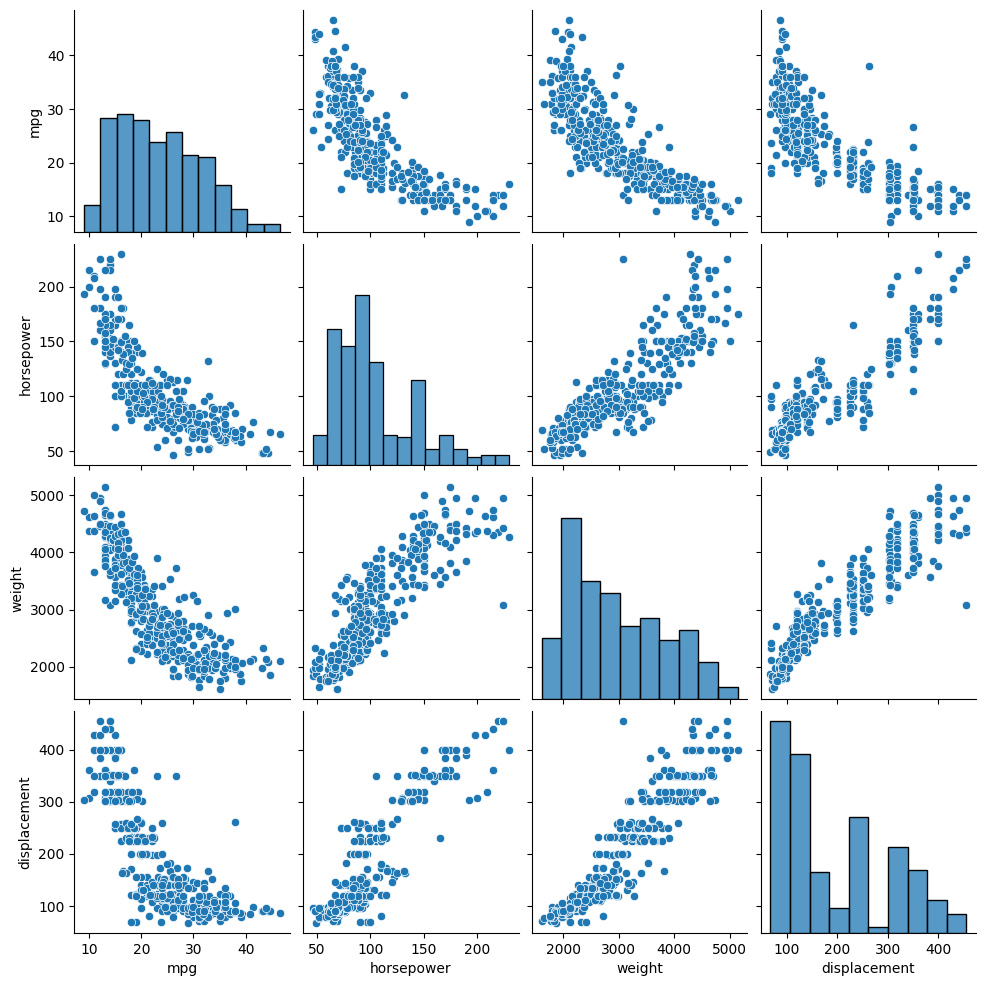

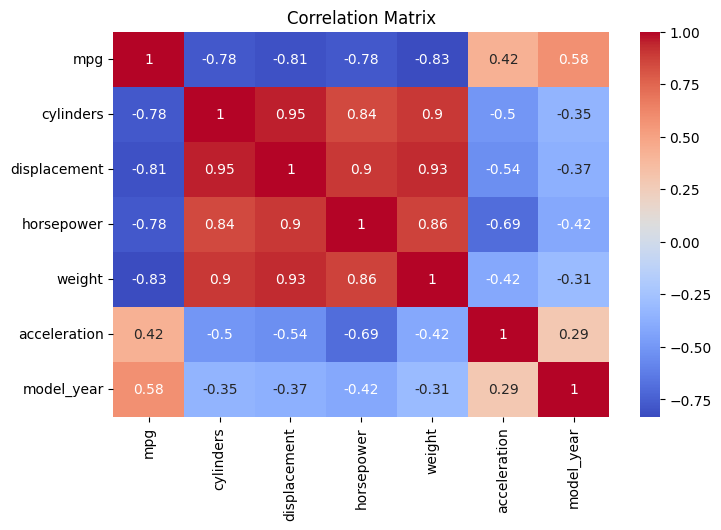

In [3]:
sb.pairplot(data[['mpg','horsepower','weight','displacement']])
plt.show()

plt.figure(figsize=(8,5))
sb.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [4]:
features = data[['horsepower','weight','acceleration','displacement']]
target = data['mpg']

In [5]:
X_tr, X_te, y_tr, y_te = train_test_split(
    features, target,
    test_size=0.25,
    random_state=1
)

In [6]:
linear_model = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

linear_model.fit(X_tr, y_tr)

lin_output = linear_model.predict(X_te)

lin_rmse = np.sqrt(mean_squared_error(y_te, lin_output))
lin_r2 = r2_score(y_te, lin_output)

print("Linear RMSE:", lin_rmse)
print("Linear R2:", lin_r2)

Linear RMSE: 4.408552997442628
Linear R2: 0.7275185174868164


In [7]:
poly_deg2 = make_pipeline(
    PolynomialFeatures(2),
    StandardScaler(),
    LinearRegression()
)

poly_deg2.fit(X_tr, y_tr)
pred_deg2 = poly_deg2.predict(X_te)

rmse_deg2 = np.sqrt(mean_squared_error(y_te, pred_deg2))
r2_deg2 = r2_score(y_te, pred_deg2)

NameError: name 'pred_deg4' is not defined

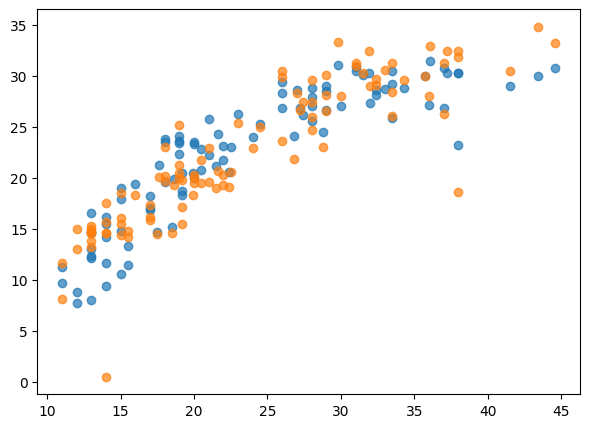

In [8]:
plt.figure(figsize=(7,5))

plt.scatter(y_te, lin_output, label="Linear", alpha=0.7)
plt.scatter(y_te, pred_deg2, label="Poly Deg2", alpha=0.7)
plt.scatter(y_te, pred_deg4, label="Poly Deg4", alpha=0.7)

plt.plot([y_te.min(), y_te.max()],
         [y_te.min(), y_te.max()],
         'k--')

plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Model Prediction Comparison")
plt.legend()
plt.show()

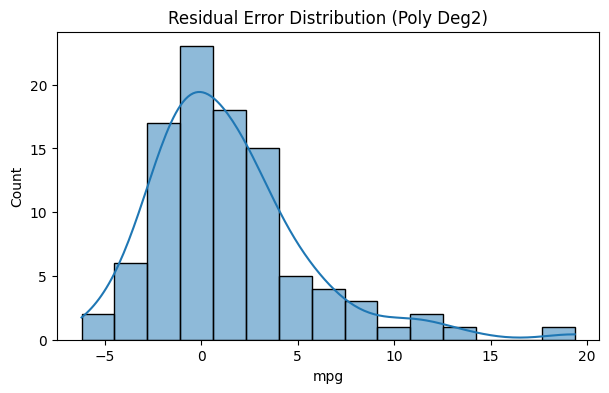

In [9]:
residuals = y_te - pred_deg2

plt.figure(figsize=(7,4))
sb.histplot(residuals, kde=True)
plt.title("Residual Error Distribution (Poly Deg2)")
plt.show()